# 02: RNNで見る次トークン予測

このNotebookでは、厚生労働省が公開している「医科診療報酬点数表」PDFから抽出したテキストを読み込み、`ここまでのトークン列 -> 次のトークン` という学習ペアを機械的に作ります。

PDF出典: https://www.mhlw.go.jp/content/12400000/001686842.pdf

主役はRNNの高度な性能ではありません。既存テキストさえあれば、次トークン予測という学習タスクでは、人手で分類ラベルを付けなくても大量の教師データを作れる、という点を観察します。

## このNotebookで扱うこと / 扱わないこと

- 扱うこと: 実PDF由来テキストのトークン化、語彙表、次トークン予測ペア、小さなRNNのloss、学習中の進捗更新、固定プロンプトからの生成例。
- 扱わないこと: 生成結果が制度上正しいか、実在制度の算定可否、医療上の判断、実務での請求判断。

同梱テキストはPDF全400ページを `pdftotext -layout` で機械抽出したものです。講義中にPDFを毎回ダウンロードしたり解析したりしないよう、抽出済みテキストを教材データとして置いています。

In [1]:
from collections import Counter
from pathlib import Path
import re

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SOURCE_URL = "https://www.mhlw.go.jp/content/12400000/001686842.pdf"

np.random.seed(7)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)


In [2]:
DATA_PATH_CANDIDATES = [
    Path("data/mhlw_ika_fee_schedule_pdf_excerpt.txt"),
    Path("02_大規模言語モデルの作り方/data/mhlw_ika_fee_schedule_pdf_excerpt.txt"),
]
DATA_PATH = next((path for path in DATA_PATH_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("mhlw_ika_fee_schedule_pdf_excerpt.txt が見つかりません。Notebookを 02_大規模言語モデルの作り方/ から開いてください。")

text = DATA_PATH.read_text(encoding="utf-8")
lines = [line for line in text.splitlines() if line.strip()]

print(f"題材テキスト: {DATA_PATH}")
print(f"PDF出典: {SOURCE_URL}")
print(f"文字数: {len(text):,}")
print(f"非空行数: {len(lines):,}")
print("冒頭の数行")
display(pd.DataFrame({"line": lines[:10]}))

題材テキスト: data/mhlw_ika_fee_schedule_pdf_excerpt.txt
PDF出典: https://www.mhlw.go.jp/content/12400000/001686842.pdf
文字数: 1,037,099
非空行数: 22,413
冒頭の数行


,line
0,出典: 厚生労働省 別表第一 医科診療報酬点数表
1,PDF URL: https://www.mhlw.go.jp/content/12400000/001686842.pdf
2,抽出範囲: PDF 全400ページ
3,抽出方法: pdftotext -layout による機械抽出
4,注意: このテキストはRNN教材用にPDFから抽出したものであり、制度上の正誤、最新版、完全性、法的解釈を保証しない。
5,別表第一
6,医科診療報酬点数表
7,［目次］
8,第１章 基本診療料
9,第１部 初・再診料


In [3]:
TOKEN_PATTERN = re.compile(r"[A-Za-zＡ-Ｚａ-ｚ]+|[0-9０-９]+(?:[.．][0-9０-９]+)?|[一-龥ぁ-んァ-ヶー]+|[^\s]")


def split_japanese_piece(piece, width=2):
    if re.fullmatch(r"[一-龥ぁ-んァ-ヶー]+", piece) and len(piece) > width:
        return [piece[index:index + width] for index in range(0, len(piece), width)]
    return [piece]


def tokenize(source_text):
    raw_pieces = TOKEN_PATTERN.findall(source_text)
    tokens = []
    for piece in raw_pieces:
        tokens.extend(split_japanese_piece(piece))
    return tokens


tokens = tokenize(text)
sample_line = "Ａ０００   初診料                                         291点"
sample_tokens = tokenize(sample_line)

print(f"総トークン数: {len(tokens):,}")
display(pd.DataFrame({
    "元の文字列": [sample_line],
    "簡易トークン化": [" / ".join(sample_tokens)],
}))

総トークン数: 298,649


,元の文字列,簡易トークン化
0,Ａ０００ 初診料 291点,Ａ / ０００ / 初診 / 料 / 291 / 点


In [22]:
token_counts = Counter(tokens)
vocab = ["<UNK>"] + [token for token, _ in token_counts.most_common()]
token_to_id = {token: token_id for token_id, token in enumerate(vocab)}
id_to_token = {token_id: token for token, token_id in token_to_id.items()}
token_ids = np.array([token_to_id[token] for token in tokens], dtype=np.int64)

print(f"語彙数: {len(vocab):,}")
display(pd.DataFrame(
    [{"token": token, "token_id": token_to_id[token], "count": count} for token, count in token_counts.most_common(20)]
))

語彙数: 13,509


,token,token_id,count
0,、,1,11304
1,点,2,7669
2,１,3,4918
3,（,4,4796
4,）,5,4791
5,。,6,4219
6,",",7,4077
7,２,8,4068
8,Ｋ,9,2650
9,入院,10,2469


In [5]:
CONTEXT_LENGTH = 16


def create_next_token_pairs(ids, context_length):
    windows = np.lib.stride_tricks.sliding_window_view(ids, context_length + 1)
    return windows[:, :context_length].copy(), windows[:, context_length].copy()


def show_token_ids(ids):
    return " ".join(id_to_token[int(token_id)] for token_id in ids)


X, y = create_next_token_pairs(token_ids, CONTEXT_LENGTH)
preview_rows = []
for index in [0, 1, 2, 800, 2_400]:
    preview_rows.append({
        "sample": index,
        "ここまでのトークン列": show_token_ids(X[index]),
        "次のトークン": id_to_token[int(y[index])],
    })

print(f"X shape = {X.shape} = [全学習ペア数, 文脈トークン数]")
print(f"y shape = {y.shape} = [次トークンID]")
print(f"1つのPDF由来テキストから作れた学習ペア数: {len(X):,}")
print("RNN学習では、この全ペアをtrain/testに分けたうえで、各epochに全プールからmini-batchをランダムサンプリングします。")
display(pd.DataFrame(preview_rows))


X shape = (298633, 16) = [全学習ペア数, 文脈トークン数]
y shape = (298633,) = [次トークンID]
1つのPDF由来テキストから作れた学習ペア数: 298,633
RNN学習では、この全ペアをtrain/testに分けたうえで、各epochに全プールからmini-batchをランダムサンプリングします。


,sample,ここまでのトークン列,次のトークン
0,0,出典 : 厚生 労働 省 別表 第一 医科 診療 報酬 点数 表 PDF URL : https,:
1,1,: 厚生 労働 省 別表 第一 医科 診療 報酬 点数 表 PDF URL : https :,/
2,2,厚生 労働 省 別表 第一 医科 診療 報酬 点数 表 PDF URL : https : /,/
3,800,た場 合に は 、 区分 番号 Ａ ０００ に掲 げる 初診 料の 注 ５ のた だし,書
4,2400,大臣 が定 める 施設 基準 に適 合し てい るも のと して 地方 厚生 局長 等 に届,け出


## 小さなRNNで次トークンを予測する

ここからは、EmbeddingでトークンIDをベクトルにし、RNNのhidden stateを順番に更新し、最後のhidden stateから次トークンの確率分布を出します。

今回は、単なる玩具実装から少しだけ実装を整えています。具体的には、全ペアを学習候補プールにし、train/test分割、mini-batchサンプリング、BPTT、勾配クリップ、Adam更新、評価サンプルによる途中評価を入れます。モデル容量も説明用として少し余裕を持たせ、Embedding 64次元、hidden state 128次元にします。

出力層ではEmbeddingを共有し、hidden stateをEmbedding空間へ写してから次トークン確率を出します。大きめのhidden stateを使いつつ、語彙13,000超のPDF由来テキストでも学習セルを扱いやすくするためです。

下の学習セルは、一定間隔で現在のlossとaccuracyの表を同じ表示領域で更新します。lossグラフは学習中に何度も作り直さず、学習後に一度だけ描画するため、画面のチカつきを抑えながら途中経過を観察できます。


In [11]:
def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum(axis=1, keepdims=True)


def initialize_rnn(vocab_size, embedding_dim=128, hidden_dim=256, seed=11):
    rng = np.random.default_rng(seed)
    return {
        "embedding": rng.normal(0, 1 / np.sqrt(embedding_dim), size=(vocab_size, embedding_dim)),
        "Wx": rng.normal(0, 1 / np.sqrt(embedding_dim), size=(embedding_dim, hidden_dim)),
        "Wh": rng.normal(0, 1 / np.sqrt(hidden_dim), size=(hidden_dim, hidden_dim)),
        "bh": np.zeros(hidden_dim),
        "Wout": rng.normal(0, 1 / np.sqrt(hidden_dim), size=(hidden_dim, embedding_dim)),
        "bout": np.zeros(embedding_dim),
        "bo": np.zeros(vocab_size),
    }


def initialize_adam_state(params):
    return {
        "m": {name: np.zeros_like(value) for name, value in params.items()},
        "v": {name: np.zeros_like(value) for name, value in params.items()},
        "t": 0,
    }


def forward_batch(params, batch_x):
    batch_size, steps = batch_x.shape
    hidden_dim = params["Wh"].shape[0]
    h = np.zeros((batch_size, hidden_dim))
    hidden_states = []
    input_embeddings = []
    for step in range(steps):
        e = params["embedding"][batch_x[:, step]]
        h = np.tanh(e @ params["Wx"] + h @ params["Wh"] + params["bh"])
        input_embeddings.append(e)
        hidden_states.append(h)
    output_features = h @ params["Wout"] + params["bout"]
    logits = output_features @ params["embedding"].T + params["bo"]
    return logits, hidden_states, input_embeddings, output_features


def choose_sample_indices(rng, total_size, sample_size):
    if sample_size is None or sample_size >= total_size:
        return np.arange(total_size)
    return rng.choice(total_size, size=sample_size, replace=False)


def evaluate_loss(params, X_eval, y_eval, batch_size=256, sample_size=None, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    eval_idx = choose_sample_indices(rng, len(X_eval), sample_size)
    losses = []
    correct = 0
    total = 0
    for start in range(0, len(eval_idx), batch_size):
        idx = eval_idx[start:start + batch_size]
        batch_x = X_eval[idx]
        batch_y = y_eval[idx]
        logits, _, _, _ = forward_batch(params, batch_x)
        probs = softmax(logits)
        losses.append(-np.log(probs[np.arange(len(batch_y)), batch_y] + 1e-12).mean())
        correct += (probs.argmax(axis=1) == batch_y).sum()
        total += len(batch_y)
    return float(np.mean(losses)), float(correct / total)


def compute_gradients(params, batch_x, batch_y):
    logits, hidden_states, input_embeddings, output_features = forward_batch(params, batch_x)
    probs = softmax(logits)
    batch_size = len(batch_y)
    loss = float(-np.log(probs[np.arange(batch_size), batch_y] + 1e-12).mean())

    dlogits = probs
    dlogits[np.arange(batch_size), batch_y] -= 1
    dlogits /= batch_size

    grads = {name: np.zeros_like(value) for name, value in params.items()}
    grads["bo"] = dlogits.sum(axis=0)
    grads["embedding"] += dlogits.T @ output_features

    d_output_features = dlogits @ params["embedding"]
    grads["Wout"] = hidden_states[-1].T @ d_output_features
    grads["bout"] = d_output_features.sum(axis=0)
    dh = d_output_features @ params["Wout"].T

    for step in reversed(range(batch_x.shape[1])):
        h = hidden_states[step]
        prev_h = np.zeros_like(h) if step == 0 else hidden_states[step - 1]
        dtanh = dh * (1 - h * h)
        grads["Wx"] += input_embeddings[step].T @ dtanh
        grads["Wh"] += prev_h.T @ dtanh
        grads["bh"] += dtanh.sum(axis=0)
        d_input_embedding = dtanh @ params["Wx"].T
        np.add.at(grads["embedding"], batch_x[:, step], d_input_embedding)
        dh = dtanh @ params["Wh"].T

    for grad in grads.values():
        np.clip(grad, -1.0, 1.0, out=grad)
    return loss, grads


def apply_adam_update(params, grads, adam_state, learning_rate, beta1=0.9, beta2=0.999, epsilon=1e-8):
    adam_state["t"] += 1
    t = adam_state["t"]
    for name in params:
        adam_state["m"][name] = beta1 * adam_state["m"][name] + (1 - beta1) * grads[name]
        adam_state["v"][name] = beta2 * adam_state["v"][name] + (1 - beta2) * (grads[name] ** 2)
        m_hat = adam_state["m"][name] / (1 - beta1 ** t)
        v_hat = adam_state["v"][name] / (1 - beta2 ** t)
        params[name] -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)


def update_rnn(params, adam_state, batch_x, batch_y, learning_rate):
    loss, grads = compute_gradients(params, batch_x, batch_y)
    apply_adam_update(params, grads, adam_state, learning_rate)
    return loss


def create_training_display():
    status_handle = display(Markdown("**学習準備中**"), display_id=True)
    table_handle = display(pd.DataFrame(columns=[
        "epoch",
        "recent_batch_loss",
        "train_loss",
        "train_accuracy",
        "test_loss",
        "test_accuracy",
    ]), display_id=True)
    return {"status": status_handle, "table": table_handle}


def build_loss_figure(history):
    fig, ax = plt.subplots(figsize=(7, 4))
    if not history.empty:
        ax.plot(history["epoch"], history["train_loss"], marker="o", label="train loss")
        ax.plot(history["epoch"], history["test_loss"], marker="o", label="test loss")
        ax.legend(loc="best")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title("Next-token prediction loss")
    ax.grid(True, alpha=0.3)
    return fig


def show_training_progress(history_rows, epoch, total_epochs, display_handles):
    history = pd.DataFrame(history_rows)
    latest = history.iloc[-1]
    status = (
        f"**学習中:** epoch {epoch} / {total_epochs}  "
        f"train loss={latest['train_loss']:.3f}, test loss={latest['test_loss']:.3f}"
    )
    display_handles["status"].update(Markdown(status))
    display_handles["table"].update(history.round(3).tail(10))


def finalize_training_progress(history_rows, display_handles):
    history = pd.DataFrame(history_rows)
    latest = history.iloc[-1]
    display_handles["status"].update(
        Markdown(
            f"**学習完了:** epoch {int(latest['epoch'])}  "
            f"train loss={latest['train_loss']:.3f}, test loss={latest['test_loss']:.3f}"
        )
    )
    display_handles["table"].update(history.round(3).tail(10))

    fig = build_loss_figure(history)
    display(fig)
    plt.close(fig)


def train_rnn(
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=1000,
    batch_size=64,
    learning_rate=0.003,
    report_every=1,
    steps_per_epoch=2,
    eval_sample_size=512,
):
    params = initialize_rnn(len(vocab))
    adam_state = initialize_adam_state(params)
    rng = np.random.default_rng(123)
    eval_rng = np.random.default_rng(456)
    history_rows = []
    recent_batch_losses = []
    display_handles = create_training_display()

    for epoch in range(epochs + 1):
        if epoch > 0:
            epoch_losses = []
            for _ in range(steps_per_epoch):
                batch_idx = rng.integers(0, len(X_train), size=batch_size)
                batch_loss = update_rnn(params, adam_state, X_train[batch_idx], y_train[batch_idx], learning_rate)
                epoch_losses.append(batch_loss)
            recent_batch_losses.append(float(np.mean(epoch_losses)))

        if epoch % report_every == 0 or epoch == epochs:
            train_loss, train_acc = evaluate_loss(
                params,
                X_train,
                y_train,
                sample_size=eval_sample_size,
                rng=eval_rng,
            )
            test_loss, test_acc = evaluate_loss(
                params,
                X_test,
                y_test,
                sample_size=eval_sample_size,
                rng=eval_rng,
            )
            history_rows.append({
                "epoch": epoch,
                "recent_batch_loss": np.mean(recent_batch_losses[-10:]) if recent_batch_losses else np.nan,
                "train_loss": train_loss,
                "train_accuracy": train_acc,
                "test_loss": test_loss,
                "test_accuracy": test_acc,
            })
            show_training_progress(history_rows, epoch, epochs, display_handles)

    finalize_training_progress(history_rows, display_handles)
    return params, pd.DataFrame(history_rows)


def predict_next_distribution(params, prompt_tokens):
    ids = [token_to_id.get(token, 0) for token in prompt_tokens]
    if len(ids) < CONTEXT_LENGTH:
        ids = [0] * (CONTEXT_LENGTH - len(ids)) + ids
    context = np.array(ids[-CONTEXT_LENGTH:], dtype=np.int64)[None, :]
    logits, _, _, _ = forward_batch(params, context)
    return softmax(logits)[0]


def generate_text(params, prompt, max_new_tokens=44, top_k=6, temperature=0.9, seed=5):
    rng = np.random.default_rng(seed)
    generated_tokens = tokenize(prompt)
    for _ in range(max_new_tokens):
        probs = predict_next_distribution(params, generated_tokens)
        logits = np.log(probs + 1e-12) / temperature
        ranked = np.argsort(logits)[-top_k:]
        top_probs = np.exp(logits[ranked] - logits[ranked].max())
        top_probs = top_probs / top_probs.sum()
        next_id = int(rng.choice(ranked, p=top_probs))
        generated_tokens.append(id_to_token[next_id])
    return "".join(generated_tokens)


train pool: 253,838 pairs
test pool: 44,795 pairs
updates per epoch: 1 mini-batches sampled from the train pool


**学習完了:** epoch 3000  train loss=1.683, test loss=3.554

,epoch,recent_batch_loss,train_loss,train_accuracy,test_loss,test_accuracy
141,2820,1.919,1.654,0.688,2.970,0.516
142,2840,1.972,2.154,0.617,3.172,0.520
143,2860,1.938,1.821,0.660,2.944,0.559
144,2880,1.844,1.662,0.664,2.879,0.574
145,2900,1.810,1.888,0.633,2.731,0.602
146,2920,1.762,1.873,0.660,2.712,0.586
147,2940,1.716,1.750,0.633,2.633,0.566
148,2960,1.809,1.903,0.633,3.086,0.508
149,2980,1.829,1.843,0.633,3.269,0.473
150,3000,1.803,1.683,0.695,3.554,0.477


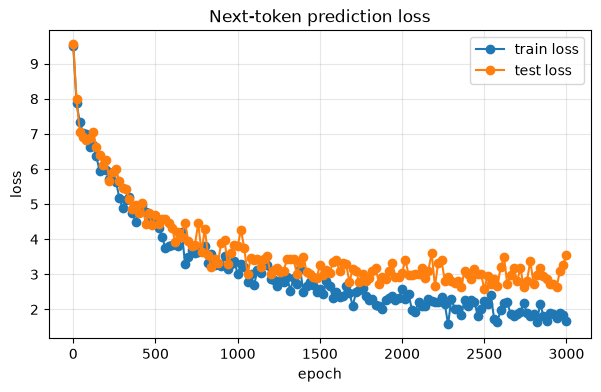

In [15]:
EPOCHS = 3000
BATCH_SIZE = 256
LEARNING_RATE = 0.001
STEPS_PER_EPOCH = 1
REPORT_EVERY = 20
EVAL_SAMPLE_SIZE = 256

rng = np.random.default_rng(42)
indices = rng.permutation(len(X))
train_size = int(len(indices) * 0.85)
train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"train pool: {len(X_train):,} pairs")
print(f"test pool: {len(X_test):,} pairs")
print(f"updates per epoch: {STEPS_PER_EPOCH} mini-batches sampled from the train pool")

untrained_params = initialize_rnn(len(vocab), seed=11)
trained_params, history = train_rnn(
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    report_every=REPORT_EVERY,
    steps_per_epoch=STEPS_PER_EPOCH,
    eval_sample_size=EVAL_SAMPLE_SIZE,
)


In [16]:
fixed_prompt = "Ａ０００ 初診料"
untrained_generation = generate_text(untrained_params, fixed_prompt, max_new_tokens=44, seed=1)
trained_generation = generate_text(trained_params, fixed_prompt, max_new_tokens=44, seed=1)

print("固定プロンプトからの生成比較")
display(pd.DataFrame([
    {"model": "学習前のRNN", "generated": untrained_generation},
    {"model": "学習後のRNN", "generated": trained_generation},
]))

固定プロンプトからの生成比較


,model,generated
0,学習前のRNN,Ａ０００初診料貼布う多の使得た顎鳥特能精事院093２８３腔的位で医の師等師等損閉居し膜電精嚢球注絆創び肛ロメ外に化診項目テノ療院942床療経内応様陰来医断し219鑑別は倍ン指ＵＤＰ靱帯高エ供し核球
1,学習後のRNN,Ａ０００初診料40点注別に厚生労働大臣が定める場合には、算定できない。５別に厚生労働大臣が定める施設基準に適合しているものとして地方厚生局長等に届け出た保険医療機関において、


In [19]:
prompt_tokens = tokenize(fixed_prompt)
next_probs = predict_next_distribution(trained_params, prompt_tokens)
top_ids = np.argsort(next_probs)[-10:][::-1]

print("2024年にワールドカップで優勝した国である")
display(pd.DataFrame({
    "token": [id_to_token[int(token_id)] for token_id in top_ids],
    "probability": [next_probs[int(token_id)] for token_id in top_ids],
}).round(4))

2024年にワールドカップで優勝した国である


,token,probability
0,１,0.2087
1,40,0.1012
2,15,0.0948
3,25,0.0353
4,６,0.0315
5,75,0.0301
6,４,0.0298
7,100,0.0296
8,50,0.0288
9,500,0.0281


In [20]:
long_prompt = "Ａ００１ 再診料"
long_generation = generate_text(trained_params, long_prompt, max_new_tokens=90, seed=9)

print("長めに生成した例")
print(long_generation)
print()
print("観察ポイント: 本物のPDF由来テキストで学習しても、点数、条件、施設基準、届出要件の整合性は保証されません。")

長めに生成した例
Ａ００１再診料1,390点注１別に厚生労働大臣が定める疾病等の患者又はその家族等の同意を得て、当該保険医療機関の保険医療機関の保険医療機関に療養上の病院又は地域医療機関の保険医療機関からの患者の場合2,000点ロその他のものに対して、入室後早期から経腸栄養をした場合であって、１日につき）１人につき１回（別に厚生労働大臣が定める状態が困

観察ポイント: 本物のPDF由来テキストで学習しても、点数、条件、施設基準、届出要件の整合性は保証されません。


## まとめ

- 実PDF由来の既存テキストをトークン化すると、トークンID列に変換できる。
- トークンID列を1つずつずらすだけで、`ここまでのトークン列 -> 次のトークン` の学習ペアを大量に作れる。
- RNNでも、次トークン予測のlossが下がり、固定プロンプトから続きを生成できる。
- 学習セルは途中経過の数値を同じ表示枠で更新し、lossグラフは学習後に一度だけ表示するため、チカつきを抑えて進み方を観察できる。
- 生成結果が制度上正しいかは、このNotebookでは扱わない。正確性、最新版、根拠、権限は、別のスライドで扱う事前学習済みLLMの限界と業務アプリ設計の論点になる。
